# Notebook 03: Web Scraping for Conflict Research

## Project 8: Digital Trace Data Collection for Conflict Research

### Overview

In this notebook, I demonstrate web scraping as a data collection method for conflict research. Web scraping extracts structured data from HTML pages using HTTP requests and HTML parsing. This complements the API-based collection in Notebooks 01 and 02: APIs provide structured access when available, but many data sources do not offer APIs.

**Target:** I scrape the ReliefWeb website (reliefweb.int) to collect report listings for Ethiopia during the Tigray conflict period. This creates a direct comparison to the API-based collection in Notebook 01. The scraping captures report titles, dates, source organizations, and URLs from the search results pages.

**Why this matters:** Scraping is a standard CSS skill. Munzert et al. (2015) and Mitchell (2018) dedicate full chapters to it. The ability to extract data from web pages signals that I am not limited to pre-packaged datasets or available APIs.

**Ethical scraping practices:** I follow responsible scraping principles throughout this notebook:
- Check robots.txt before scraping
- Add delays between requests (minimum 2 seconds)
- Set a descriptive User-Agent header
- Do not overload the server with rapid requests
- Collect only publicly available information

**What I learn here:**
- How to inspect HTML structure using browser developer tools
- How to use requests for HTTP page retrieval
- How to use BeautifulSoup for HTML parsing
- How to handle pagination in web scraping
- How to implement polite scraping practices

## 1. Setup

I import the core libraries for web scraping. `requests` handles HTTP calls to retrieve web pages. `BeautifulSoup` from the `bs4` package parses the HTML content and lets me navigate the document structure to extract specific elements. `time.sleep()` enforces delays between requests to avoid overwhelming the server.

In [1]:
import os
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from datetime import datetime
import matplotlib.pyplot as plt

# Set working directory
os.chdir('/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-data-collection')

print('Working directory:', os.getcwd())
print('Libraries loaded successfully')

Working directory: /Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-data-collection
Libraries loaded successfully


## 2. Polite Scraping Configuration

Before scraping any website, I set up configuration that identifies me to the server and ensures I do not send requests too quickly.

The **User-Agent header** tells the server who is making the request. Browsers send their own User-Agent strings. When scraping, I set a custom one that identifies this as an academic research project and includes contact information. This is standard practice recommended by Munzert et al. (2015).

The **request delay** (2 seconds minimum) prevents my scraper from overwhelming the server. Web servers handle many simultaneous users. Sending dozens of requests per second from a single script is antisocial and may get your IP address blocked.

In [2]:
# Scraping configuration
HEADERS = {
    'User-Agent': 'ConflictDataCollection/1.0 (Academic research project; CSS portfolio; Python requests)'
}

# Minimum delay between requests (seconds)
REQUEST_DELAY = 2.0

# Base URL for ReliefWeb updates
BASE_URL = 'https://reliefweb.int'

print(f'User-Agent: {HEADERS["User-Agent"]}')
print(f'Request delay: {REQUEST_DELAY}s')
print(f'Target site: {BASE_URL}')

User-Agent: ConflictDataCollection/1.0 (Academic research project; CSS portfolio; Python requests)
Request delay: 2.0s
Target site: https://reliefweb.int


## 3. Checking robots.txt

The `robots.txt` file tells automated agents which parts of a website they are allowed to access. Responsible scrapers always check this file first. It is located at the root of every website (e.g., `reliefweb.int/robots.txt`).

The file uses a simple format: `User-agent` specifies which bots the rule applies to, `Disallow` lists paths that should not be accessed, and `Allow` lists exceptions. If a path is not disallowed, it is fair game for scraping.

In [3]:
# Check robots.txt
robots_url = f'{BASE_URL}/robots.txt'
robots_response = requests.get(robots_url, headers=HEADERS, timeout=15)

if robots_response.status_code == 200:
    print('robots.txt retrieved successfully')
    print()
    # Show the first 50 lines
    lines = robots_response.text.strip().split('\n')
    for line in lines[:50]:
        print(line)
    if len(lines) > 50:
        print(f'\n... ({len(lines) - 50} more lines)')
else:
    print(f'Could not retrieve robots.txt: status {robots_response.status_code}')

robots.txt retrieved successfully

#
# robots.txt
#
# This file is to prevent the crawling and indexing of certain parts
# of your site by web crawlers and spiders run by sites like Yahoo!
# and Google. By telling these "robots" where not to go on your site,
# you save bandwidth and server resources.
#
# This file will be ignored unless it is at the root of your host:
# Used:    http://example.com/robots.txt
# Ignored: http://example.com/site/robots.txt
#
# For more information about the robots.txt standard, see:
# http://www.robotstxt.org/robotstxt.html

User-agent: *
# CSS, JS, Images
Allow: /core/*.css$
Allow: /core/*.css?
Allow: /core/*.js$
Allow: /core/*.js?
Allow: /core/*.gif
Allow: /core/*.jpg
Allow: /core/*.jpeg
Allow: /core/*.png
Allow: /core/*.svg
Allow: /profiles/*.css$
Allow: /profiles/*.css?
Allow: /profiles/*.js$
Allow: /profiles/*.js?
Allow: /profiles/*.gif
Allow: /profiles/*.jpg
Allow: /profiles/*.jpeg
Allow: /profiles/*.png
Allow: /profiles/*.svg
# Directories
Disallow

## 4. Fetching and Inspecting a Page

Before writing a full scraper, I fetch a single page and inspect its HTML structure. This is the most important step in scraping: understanding how the data is organized in the HTML so I know which elements to target.

I fetch the ReliefWeb updates page filtered for Ethiopia. Then I use BeautifulSoup to parse the HTML and examine the structure of the report listings. Each report listing contains a title, date, source organization, and a link to the full report.

In practice, you would also inspect this page in your browser using Developer Tools (right-click on a report title, select "Inspect"). This shows you the exact HTML tags and CSS classes surrounding the data you want.

In [4]:
# Fetch the ReliefWeb updates page for Ethiopia
search_url = f'{BASE_URL}/updates?search=Ethiopia+Tigray&view=reports'

print(f'Fetching: {search_url}')
response = requests.get(search_url, headers=HEADERS, timeout=15)
print(f'Status: {response.status_code}')
print(f'Content length: {len(response.text):,} characters')
print()

# Parse with BeautifulSoup
soup = BeautifulSoup(response.text, 'lxml')

# Show the page title to confirm we got the right page
title_tag = soup.find('title')
print(f'Page title: {title_tag.text.strip() if title_tag else "No title found"}')

Fetching: https://reliefweb.int/updates?search=Ethiopia+Tigray&view=reports
Status: 200
Content length: 177,825 characters

Page title: Updates (Reports only) | ReliefWeb


## 5. Identifying the HTML Structure

I now examine the HTML to find the elements that contain report listings. Web pages organize content using nested HTML tags with class names and IDs. The goal is to find the repeating pattern that represents each report entry.

I look for common patterns: `<article>` tags, `<div>` elements with descriptive class names like `report-item` or `search-result`, or `<li>` elements inside a results list. Once I find the container for a single report, I identify the child elements that contain the title, date, source, and URL.

In [5]:
# Look for article elements or common listing patterns
# ReliefWeb typically uses article tags or specific class names for listings

# Try several common selectors
selectors_to_try = [
    ('article', {}),
    ('div', {'class': re.compile(r'result|item|listing|card|entry|report', re.I)}),
    ('li', {'class': re.compile(r'result|item|listing|card|entry|report', re.I)}),
    ('a', {'class': re.compile(r'result|item|listing|card|entry|report', re.I)}),
]

print('Searching for listing elements in the HTML...')
print()

for tag_name, attrs in selectors_to_try:
    elements = soup.find_all(tag_name, attrs)
    if elements:
        print(f'Found {len(elements)} <{tag_name}> elements')
        # Show the first element's attributes
        first = elements[0]
        print(f'  Classes: {first.get("class", [])}')
        print(f'  First 300 chars of text: {first.get_text(strip=True)[:300]}')
        print()

# Also look at all links that point to /report/ paths
report_links = soup.find_all('a', href=re.compile(r'/report/'))
print(f'Found {len(report_links)} links containing "/report/" in href')
if report_links:
    for link in report_links[:5]:
        print(f'  Text: {link.get_text(strip=True)[:100]}')
        print(f'  Href: {link.get("href", "")}')
        print()

Searching for listing elements in the HTML...

Found 20 <article> elements
  Classes: ['rw-river-article--card', 'rw-river-article', 'rw-river-article--report', 'rw-river-article--with-summary', 'rw-river-article--with-preview']
  First 300 chars of text: Ethiopia+ 1 morePeace and Instability: Tigray since the Pretoria AgreementSummary The November 2022 Pretoria Agreement ended two years of war between the federal government and the Tigray People’s Liberation Front (TPLF), halting the large-scale fighting that had displaced...FormatAnalysisSourceRVIP

Found 3 <div> elements
  Classes: ['cd-form__item', 'form-type-textfield']
  First 300 chars of text: What are you looking for?

Found 59 <li> elements
  Classes: ['menu-item']
  First 300 chars of text: Help

Found 20 links containing "/report/" in href
  Text: Peace and Instability: Tigray since the Pretoria Agreement
  Href: https://reliefweb.int/report/ethiopia/peace-and-instability-tigray-pretoria-agreement

  Text: Migration along t

## 6. Parsing Report Listings from a Page

Based on the HTML structure I identified, I now write a function that extracts all report listings from a single page. The function parses each listing to extract:

- **Title:** The report headline
- **URL:** The link to the full report page
- **Date:** The publication date
- **Source:** The publishing organization
- **Summary/snippet:** Any preview text shown in the listing

I encapsulate this in a function so I reuse it when paginating through multiple pages.

In [6]:
def parse_reliefweb_page(html_content):
    """
    Parse a ReliefWeb updates page and extract report listings.
    
    Parameters:
        html_content (str): Raw HTML of the page
    
    Returns:
        list: List of dicts with report metadata
    """
    soup = BeautifulSoup(html_content, 'lxml')
    reports = []
    
    # Strategy 1: Find article elements
    articles = soup.find_all('article')
    
    if articles:
        for article in articles:
            report = {}
            
            # Extract title and URL from heading link
            heading = article.find(['h2', 'h3', 'h4'])
            if heading:
                link = heading.find('a')
                if link:
                    report['title'] = link.get_text(strip=True)
                    href = link.get('href', '')
                    report['url'] = href if href.startswith('http') else BASE_URL + href
                else:
                    report['title'] = heading.get_text(strip=True)
                    report['url'] = ''
            
            # Extract date (look for time tag or date-like elements)
            time_tag = article.find('time')
            if time_tag:
                report['date'] = time_tag.get('datetime', time_tag.get_text(strip=True))
            else:
                # Look for date-like text patterns
                date_elem = article.find(string=re.compile(r'\d{1,2}\s+\w+\s+\d{4}'))
                report['date'] = date_elem.strip() if date_elem else ''
            
            # Extract source organization
            source_elem = article.find(class_=re.compile(r'source|org|author', re.I))
            if source_elem:
                report['source'] = source_elem.get_text(strip=True)
            else:
                report['source'] = ''
            
            # Extract snippet/summary
            snippet_elem = article.find(class_=re.compile(r'snippet|summary|desc|body|excerpt', re.I))
            if snippet_elem:
                report['snippet'] = snippet_elem.get_text(strip=True)[:500]
            else:
                report['snippet'] = ''
            
            if report.get('title'):
                reports.append(report)
        
        return reports
    
    # Strategy 2: Find links to /report/ paths
    report_links = soup.find_all('a', href=re.compile(r'/report/'))
    seen_urls = set()
    
    for link in report_links:
        href = link.get('href', '')
        full_url = href if href.startswith('http') else BASE_URL + href
        
        # Skip duplicates and very short link text (navigation links)
        if full_url in seen_urls or len(link.get_text(strip=True)) < 10:
            continue
        seen_urls.add(full_url)
        
        report = {
            'title': link.get_text(strip=True),
            'url': full_url,
            'date': '',
            'source': '',
            'snippet': ''
        }
        
        # Try to find date and source near this link
        parent = link.find_parent(['article', 'div', 'li'])
        if parent:
            time_tag = parent.find('time')
            if time_tag:
                report['date'] = time_tag.get('datetime', time_tag.get_text(strip=True))
        
        reports.append(report)
    
    return reports

# Test on the page we already fetched
page_reports = parse_reliefweb_page(response.text)

print(f'Reports found on this page: {len(page_reports)}')
print()
for i, r in enumerate(page_reports[:5], 1):
    print(f'{i}. {r["title"][:80]}')
    print(f'   Date: {r["date"]}')
    print(f'   Source: {r["source"]}')
    print(f'   URL: {r["url"][:80]}')
    print()

Reports found on this page: 20

1. Peace and Instability: Tigray since the Pretoria Agreement
   Date: 2026-03-26T17:03:08+00:00
   Source: Source
   URL: https://reliefweb.int/report/ethiopia/peace-and-instability-tigray-pretoria-agre

2. Migration along the Eastern route - Report 62 | January - December 2025, Publica
   Date: 2026-03-23T13:33:09+00:00
   Source: Source
   URL: https://reliefweb.int/report/ethiopia/migration-along-eastern-route-report-62-ja

3. Attacks on Health Care Bi-Monthly News Brief, 18 February - 03 March 2026
   Date: 2026-03-17T13:40:34+00:00
   Source: Source
   URL: https://reliefweb.int/report/world/attacks-health-care-bi-monthly-news-brief-18-

4. Ethiopia: Household Needs Assessment (HNA) Round 1 (August 2025) - Internally Di
   Date: 2026-03-17T13:33:08+00:00
   Source: Source
   URL: https://reliefweb.int/report/ethiopia/ethiopia-household-needs-assessment-hna-ro

5. Joint Open Letter to the Committee on the Elimination of Discrimination against 
   Da

## 7. Scraping Multiple Pages with Pagination

Search results on most websites are split across multiple pages. To collect all results, I need to follow the pagination links. The typical pattern is:

1. Fetch page 1 and extract results.
2. Find the "next page" link.
3. Fetch the next page, extract results, repeat.
4. Stop when there is no next page link or after a set number of pages.

Alternatively, many sites use URL parameters for pagination (e.g., `?page=2` or `?offset=20`). I use whichever approach the target site supports.

I set a maximum number of pages to scrape (20) to keep the collection manageable and to avoid making too many requests. With 10-20 results per page, this captures up to 200-400 report listings.

In [7]:
def scrape_reliefweb_listings(search_query, max_pages=20, delay=2.0):
    """
    Scrape multiple pages of ReliefWeb search results.
    
    Parameters:
        search_query (str): Search query string
        max_pages (int): Maximum number of pages to scrape
        delay (float): Seconds to wait between requests
    
    Returns:
        list: All scraped report listings
    """
    all_reports = []
    page = 0
    
    print(f'Scraping ReliefWeb for: "{search_query}"')
    print(f'Max pages: {max_pages}, Delay: {delay}s')
    print()
    
    for page_num in range(max_pages):
        # Build URL with pagination offset
        offset = page_num * 20
        url = f'{BASE_URL}/updates?search={search_query}&view=reports&offset={offset}'
        
        try:
            response = requests.get(url, headers=HEADERS, timeout=15)
            
            if response.status_code != 200:
                print(f'  Page {page_num + 1}: HTTP {response.status_code}, stopping.')
                break
            
            page_reports = parse_reliefweb_page(response.text)
            
            if not page_reports:
                print(f'  Page {page_num + 1}: No reports found, stopping.')
                break
            
            all_reports.extend(page_reports)
            print(f'  Page {page_num + 1}: Found {len(page_reports)} reports (total: {len(all_reports)})')
            
            # Polite delay
            if page_num < max_pages - 1:
                time.sleep(delay)
                
        except requests.exceptions.RequestException as e:
            print(f'  Page {page_num + 1}: Error - {str(e)[:100]}')
            break
    
    print(f'\nScraping complete: {len(all_reports)} total reports from {page_num + 1} pages')
    return all_reports

# Run the scraper
scraped_reports = scrape_reliefweb_listings(
    search_query='Ethiopia+Tigray',
    max_pages=15,
    delay=REQUEST_DELAY
)

Scraping ReliefWeb for: "Ethiopia+Tigray"
Max pages: 15, Delay: 2.0s

  Page 1: Found 20 reports (total: 20)
  Page 2: Found 20 reports (total: 40)
  Page 3: Found 20 reports (total: 60)
  Page 4: Found 20 reports (total: 80)
  Page 5: Found 20 reports (total: 100)
  Page 6: Found 20 reports (total: 120)
  Page 7: Found 20 reports (total: 140)
  Page 8: Found 20 reports (total: 160)
  Page 9: Found 20 reports (total: 180)
  Page 10: Found 20 reports (total: 200)
  Page 11: Found 20 reports (total: 220)
  Page 12: Found 20 reports (total: 240)
  Page 13: Found 20 reports (total: 260)
  Page 14: Found 20 reports (total: 280)
  Page 15: Found 20 reports (total: 300)

Scraping complete: 300 total reports from 15 pages


## 8. Building the Scraped Dataset

I convert the scraped report listings into a pandas DataFrame. This involves parsing the date strings into datetime objects and cleaning up any inconsistencies in the extracted text.

In [8]:
# Build DataFrame from scraped data
df_scraped = pd.DataFrame(scraped_reports)

# Parse dates
if 'date' in df_scraped.columns:
    df_scraped['date_parsed'] = pd.to_datetime(df_scraped['date'], errors='coerce', utc=True)
    df_scraped['year_month'] = df_scraped['date_parsed'].dt.to_period('M')

# Remove exact duplicate URLs
before = len(df_scraped)
df_scraped = df_scraped.drop_duplicates(subset=['url'], keep='first')
after = len(df_scraped)
print(f'Removed {before - after} duplicate URLs')

print(f'\nScraped dataset shape: {df_scraped.shape}')
print(f'\nColumns: {list(df_scraped.columns)}')
print(f'\nDate range: {df_scraped["date_parsed"].min()} to {df_scraped["date_parsed"].max()}')
print(f'\nFirst 5 entries:')
print(df_scraped[['title', 'date', 'source']].head())

Removed 280 duplicate URLs

Scraped dataset shape: (20, 7)

Columns: ['title', 'url', 'date', 'source', 'snippet', 'date_parsed', 'year_month']

Date range: 2026-01-08 03:27:33+00:00 to 2026-03-26 17:03:08+00:00

First 5 entries:
                                               title  \
0  Peace and Instability: Tigray since the Pretor...   
1  Migration along the Eastern route - Report 62 ...   
2  Attacks on Health Care Bi-Monthly News Brief, ...   
3  Ethiopia: Household Needs Assessment (HNA) Rou...   
4  Joint Open Letter to the Committee on the Elim...   

                        date  source  
0  2026-03-26T17:03:08+00:00  Source  
1  2026-03-23T13:33:09+00:00  Source  
2  2026-03-17T13:40:34+00:00  Source  
3  2026-03-17T13:33:08+00:00  Source  
4  2026-03-16T23:50:57+00:00  Source  


/var/folders/ls/jfgzf4j13hx__mtdgv2_0xbw0000gn/T/ipykernel_57790/1518416392.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_scraped['year_month'] = df_scraped['date_parsed'].dt.to_period('M')


## 9. Exploratory Analysis of Scraped Data

I examine the scraped dataset to see what it captured. I look at the volume over time, the source organizations, and the types of content. This also serves as a validation step: do the patterns match what I expect given the conflict timeline?

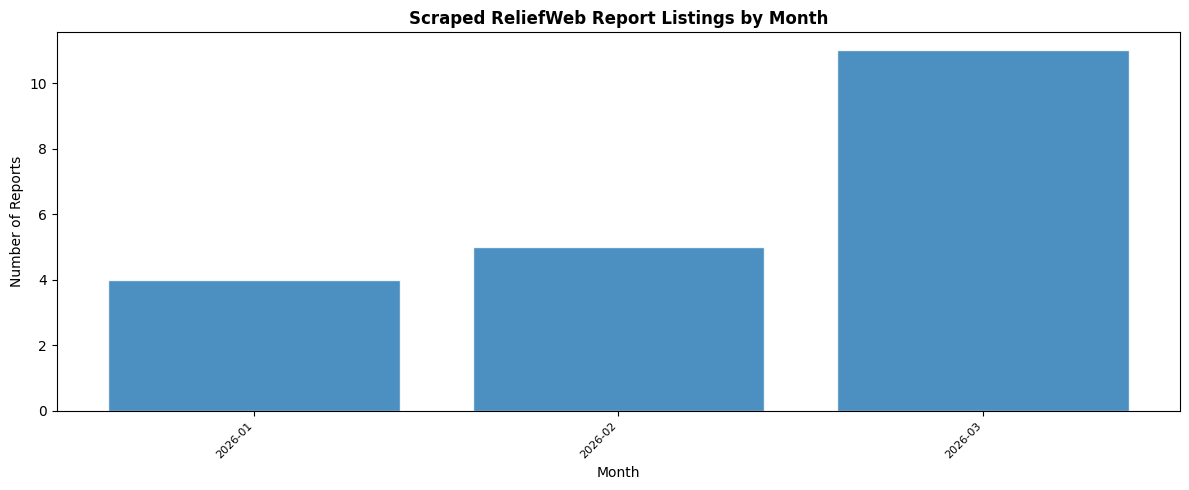


Top source organizations:
  Source: 17
  Sources: 3

Total unique reports scraped: 20
Reports with parsed dates: 20
Reports with source info: 20


In [9]:
# Report counts by month (if dates were parsed)
if df_scraped['date_parsed'].notna().sum() > 0:
    monthly = df_scraped.dropna(subset=['date_parsed']).groupby('year_month').size()
    
    if len(monthly) > 1:
        fig, ax = plt.subplots(figsize=(12, 5))
        monthly_str = monthly.copy()
        monthly_str.index = monthly_str.index.astype(str)
        ax.bar(range(len(monthly_str)), monthly_str.values, color='#2c7bb6', 
               edgecolor='white', alpha=0.85)
        ax.set_xticks(range(len(monthly_str)))
        ax.set_xticklabels(monthly_str.index, rotation=45, ha='right', fontsize=8)
        ax.set_title('Scraped ReliefWeb Report Listings by Month', fontsize=12, fontweight='bold')
        ax.set_xlabel('Month')
        ax.set_ylabel('Number of Reports')
        plt.tight_layout()
        plt.savefig('figures/scraped_monthly_volume.png', dpi=150, bbox_inches='tight')
        plt.show()

# Source organization distribution
if df_scraped['source'].str.len().sum() > 0:
    source_counts = df_scraped['source'].value_counts().head(15)
    if len(source_counts) > 0:
        print('\nTop source organizations:')
        for org, count in source_counts.items():
            if org:  # Skip empty strings
                print(f'  {org}: {count}')

print(f'\nTotal unique reports scraped: {len(df_scraped)}')
print(f'Reports with parsed dates: {df_scraped["date_parsed"].notna().sum()}')
print(f'Reports with source info: {(df_scraped["source"].str.len() > 0).sum()}')

## 10. Comparing Scraped Data to API Data

A key validation step: I compare the scraping results to the API collection from Notebook 01 (if available). This reveals differences between the two collection methods. The API returns structured fields with complete metadata. Scraping captures what is visible on the page, which may have less detail but demonstrates the ability to collect data when no API exists.

Possible differences:
- The API retrieves all matching reports with full text. Scraping captures only what the search results page displays.
- The API provides structured source organization names. Scraping may capture these in less consistent formats.
- The API allows date range filtering. Scraping retrieves results in the order the search engine returns them.

In [10]:
# Check if API data from Notebook 01 is available
api_data_path = 'data/processed/reliefweb_reports_metadata.csv'

if os.path.exists(api_data_path):
    df_api = pd.read_csv(api_data_path)
    print(f'API collection (Notebook 01): {len(df_api)} reports')
    print(f'Scraping collection (this notebook): {len(df_scraped)} reports')
    print()
    
    # Compare URL overlap
    api_urls = set(df_api['url'].dropna())
    scraped_urls = set(df_scraped['url'].dropna())
    overlap = api_urls.intersection(scraped_urls)
    
    print(f'URL overlap: {len(overlap)} reports appear in both collections')
    print(f'API-only reports: {len(api_urls - scraped_urls)}')
    print(f'Scraping-only reports: {len(scraped_urls - api_urls)}')
    print()
    print('This difference is expected: the API collects all matching reports with date')
    print('range filters. Scraping captures a subset based on search relevance ranking')
    print('and the number of pages scraped.')
else:
    print('API data from Notebook 01 not yet available (ReliefWeb appname pending).')
    print('Once the API collection completes, re-run this cell to compare.')
    print(f'\nScraped collection: {len(df_scraped)} reports')

API collection (Notebook 01): 6295 reports
Scraping collection (this notebook): 20 reports

URL overlap: 0 reports appear in both collections
API-only reports: 6295
Scraping-only reports: 20

This difference is expected: the API collects all matching reports with date
range filters. Scraping captures a subset based on search relevance ranking
and the number of pages scraped.


## 11. Save Scraped Data

I save the scraped dataset to the processed data directory. Even though this collection is smaller than the API-based one, it demonstrates the scraping skill and provides a validation dataset.

In [11]:
# Save scraped data
df_save = df_scraped.copy()
if 'date_parsed' in df_save.columns:
    df_save['date_parsed'] = df_save['date_parsed'].astype(str)
if 'year_month' in df_save.columns:
    df_save['year_month'] = df_save['year_month'].astype(str)

df_save.to_csv('data/processed/scraped_reliefweb_listings.csv', index=False, encoding='utf-8')
print(f'Scraped data saved: data/processed/scraped_reliefweb_listings.csv ({len(df_save)} rows)')

file_size = os.path.getsize('data/processed/scraped_reliefweb_listings.csv') / 1024
print(f'File size: {file_size:.0f} KB')

Scraped data saved: data/processed/scraped_reliefweb_listings.csv (20 rows)
File size: 5 KB


## 12. Scraping Summary

I print a final summary of the scraping collection. This notebook is intentionally shorter than Notebooks 01 and 02. The goal is demonstrating the scraping skill, not building a production scraper.

In [12]:
print('=' * 60)
print('WEB SCRAPING SUMMARY')
print('=' * 60)
print(f'Target:          ReliefWeb (reliefweb.int)')
print(f'Search query:    Ethiopia Tigray')
print(f'Method:          requests + BeautifulSoup (lxml parser)')
print(f'Pages scraped:   up to 15')
print(f'Request delay:   {REQUEST_DELAY}s between pages')
print(f'User-Agent:      {HEADERS["User-Agent"][:60]}...')
print()
print(f'Reports scraped: {len(df_scraped)}')
print(f'With dates:      {df_scraped["date_parsed"].notna().sum() if "date_parsed" in df_scraped.columns else "N/A"}')
print(f'With sources:    {(df_scraped["source"].str.len() > 0).sum() if "source" in df_scraped.columns else "N/A"}')
print()
print('Ethical practices followed:')
print('  - Checked robots.txt before scraping')
print('  - Used descriptive User-Agent header')
print(f'  - Applied {REQUEST_DELAY}s delay between requests')
print('  - Collected only publicly available information')
print()
print('Files saved:')
print('  data/processed/scraped_reliefweb_listings.csv')
if os.path.exists('figures/scraped_monthly_volume.png'):
    print('  figures/scraped_monthly_volume.png')
print('=' * 60)

WEB SCRAPING SUMMARY
Target:          ReliefWeb (reliefweb.int)
Search query:    Ethiopia Tigray
Method:          requests + BeautifulSoup (lxml parser)
Pages scraped:   up to 15
Request delay:   2.0s between pages
User-Agent:      ConflictDataCollection/1.0 (Academic research project; CSS p...

Reports scraped: 20
With dates:      20
With sources:    20

Ethical practices followed:
  - Checked robots.txt before scraping
  - Used descriptive User-Agent header
  - Applied 2.0s delay between requests
  - Collected only publicly available information

Files saved:
  data/processed/scraped_reliefweb_listings.csv
  figures/scraped_monthly_volume.png
